## A Cross Asset Portfolio Optimization Framework Based on Crypto Mental Synthesis

This project implements a comprehensive cross-asset analysis and portfolio optimization framework to evaluate how cryptocurrencies interact with traditional assets like gold and treasury yields from 2015 to 2025. By utilizing quantitative techniques such as Pearson correlation, Mutual Information, and the Markowitz Mean-Variance model, it analyzes risk regimes based on VIX thresholds to construct Minimum Volatility and Maximum Sharpe Ratio portfolios. The ultimate purpose is to provide a data-driven strategy for maximizing risk-adjusted returns and understanding the diversification benefits of digital assets within a broader macro-economic context.

## Structure of Analysis  
* Part 0: Import Necessary Packages  
* Part 1: Loading Data From Yahoo Finance  
* Part 2: Data Preprocessing  
* Part 3: Data Descriptive Statistics and Correlation Analysis  
* Part 4: Capital Asset Pricing Model Analysis  

### Part 0: Import Necessary Packages

In [1]:
# Import essential libraries for financial data analysis and visualization
# pandas and numpy provide data manipulation and numerical computation capabilities
# yfinance enables retrieval of historical market data from Yahoo Finance
# matplotlib and seaborn offer comprehensive visualization tools
# sklearn and statsmodels support statistical modeling and feature analysis
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
from openbb import obb
from sklearn.feature_selection import mutual_info_regression
import statsmodels.api as sm

# Configure network proxy settings for data retrieval
# This configuration is environment specific and may require adjustment
proxy = 'http://127.0.0.1:7890'
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy

### Part 1: Loading Data From Yahoo Finance 

In [3]:
# Initial data retrieval test using gold futures as benchmark asset
# GC=F represents gold futures contracts traded on COMEX
# The ten year period from 2015 to 2025 captures multiple market cycles
gold = yf.download("GC=F", start="2015-01-01", end="2025-01-01")
# Display first five observations to verify data structure and quality
print(gold.head())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2015-01-02  1186.000000  1194.500000  1169.500000  1184.000000    138
2015-01-05  1203.900024  1206.900024  1180.099976  1180.300049    470
2015-01-06  1219.300049  1220.000000  1203.500000  1203.500000     97
2015-01-07  1210.599976  1219.199951  1210.599976  1219.199951     29
2015-01-08  1208.400024  1215.699951  1206.300049  1207.000000     92


In [4]:
# Define analysis period starting from January 1st 2015
# This date marks the beginning of our multi asset study period
start_date = '2015-01-01'

# Function to retrieve Bitcoin price data from Yahoo Finance
# BTC-USD represents Bitcoin priced in US dollars
# Extracts OHLCV data and renames columns with asset prefix for clarity
def get_btc():
    btc = yf.download("BTC-USD", start=start_date)
    btc = btc[['Open','High','Low','Close','Volume']]
    btc.columns = ['btc_open','btc_high','btc_low','btc_close','btc_volume']
    return btc

# Function to retrieve Ethereum price data
# ETH-USD represents Ethereum priced in US dollars
# Maintains consistent column naming convention across all assets
def get_eth():
    eth = yf.download("ETH-USD", start=start_date)
    eth = eth[['Open','High','Low','Close','Volume']]
    eth.columns = ['eth_open','eth_high','eth_low','eth_close','eth_volume']
    return eth

# Function to retrieve Tether price data
# USDT-USD represents Tether stablecoin priced in US dollars
# USDT serves as a proxy for stablecoin market behavior
def get_usdt():
    usdt = yf.download("USDT-USD", start=start_date)
    usdt = usdt[['Open','High','Low','Close','Volume']]
    usdt.columns = ['usdt_open','usdt_high','usdt_low','usdt_close','usdt_volume']
    return usdt

# Function to retrieve gold futures price data
# GC=F represents COMEX gold futures contracts
# Gold serves as traditional safe haven asset in portfolio analysis
def get_gold():
    gold = yf.download("GC=F", start=start_date)
    gold = gold[['Open','High','Low','Close','Volume']]
    gold.columns = ['gold_open','gold_high','gold_low','gold_close','gold_volume']
    return gold

# Function to retrieve silver futures price data
# SI=F represents COMEX silver futures contracts
# Silver exhibits higher volatility compared to gold
def get_silver():
    silver = yf.download("SI=F", start=start_date)
    silver = silver[['Open','High','Low','Close','Volume']]
    silver.columns = ['silver_open','silver_high','silver_low','silver_close','silver_volume']
    return silver

# Function to retrieve copper futures price data
# HG=F represents COMEX high grade copper futures
# Copper serves as industrial metal and economic indicator
def get_copper():
    copper = yf.download("HG=F", start=start_date)
    copper = copper[['Open','High','Low','Close','Volume']]
    copper.columns = ['copper_open','copper_high','copper_low','copper_close','copper_volume']
    return copper

# Function to retrieve CBOE Volatility Index data
# ^VIX measures expected 30 day volatility of S&P 500
# VIX serves as fear gauge and risk sentiment indicator
def get_vix():
    vix = yf.download("^VIX", start=start_date)
    vix = vix[['Close']]
    vix.columns = ['vix']
    return vix

# Function to retrieve US Dollar Index data
# DX-Y.NYB represents trade weighted dollar index
# DXY reflects dollar strength against major currencies
def get_dxy():
    dxy = yf.download("DX-Y.NYB", start=start_date)
    dxy = dxy[['Close']]
    dxy.columns = ['dxy']
    return dxy

# Function to retrieve 10 Year Treasury Yield data
# ^TNX represents CBOE 10 Year Treasury Note Yield Index
# TNX serves as benchmark for risk free rate and interest rate expectations
def get_tnx():
    tnx = yf.download("^TNX", start=start_date)
    tnx = tnx[['Close']]
    tnx.columns = ['tnx']
    return tnx

# Function to estimate Bitcoin market capitalization
# Uses approximate circulating supply of 19 million BTC
# Market cap provides scale context for Bitcoin relative to traditional assets
def get_btc_marketcap():
    df = yf.download("BTC-USD", start=start_date)
    supply = 19_000_000
    df['btc_marketcap'] = df['Close'] * supply
    return df[['btc_marketcap']]

# Execute all data retrieval functions to build complete dataset
btc = get_btc()
eth = get_eth()
usdt = get_usdt()
gold = get_gold()
silver = get_silver()
copper = get_copper()
vix = get_vix()
dxy = get_dxy()
tnx = get_tnx()
mcap = get_btc_marketcap()

# Display sample data from each asset for verification
print("BTC:")
print(btc.head())
print("\nETH:")
print(eth.head())
print("\nUSDT:")
print(usdt.head())
print("\nGold:")
print(gold.head())
print("\nSilver:")
print(silver.head())
print("\nCopper:")
print(copper.head())
print("\nVIX:")
print(vix.head())
print("\nDXY:")
print(dxy.head())
print("\nTNX (10-Year Treasury Yield):")
print(tnx.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

BTC:
              btc_open    btc_high     btc_low   btc_close  btc_volume
Date                                                                  
2015-01-01  320.434998  320.434998  314.002991  314.248993     8036550
2015-01-02  314.079010  315.838989  313.565002  315.032013     7860650
2015-01-03  314.846008  315.149994  281.082001  281.082001    33054400
2015-01-04  281.145996  287.230011  257.612000  264.195007    55629100
2015-01-05  265.084015  278.341003  265.084015  274.473999    43962800

ETH:
              eth_open    eth_high     eth_low   eth_close  eth_volume
Date                                                                  
2017-11-09  308.644989  329.451996  307.056000  320.884003   893249984
2017-11-10  320.670990  324.717987  294.541992  299.252991   885985984
2017-11-11  298.585999  319.453003  298.191986  314.681000   842300992
2017-11-12  314.690002  319.153015  298.513000  307.907990  1613479936
2017-11-13  307.024994  328.415009  307.024994  316.716003  104188

### Part 2: Data Preprocessing

In [5]:
# Verify column hierarchy structure in each DataFrame
# yfinance may return MultiIndex columns depending on download parameters
# Single level columns indicate standard DataFrame structure
# MultiIndex columns require flattening before merge operations
print("btc column levels:", btc.columns.nlevels)
print("eth column levels:", eth.columns.nlevels)
print("usdt column levels:", usdt.columns.nlevels)
print("gold column levels:", gold.columns.nlevels)
print("silver column levels:", silver.columns.nlevels)
print("copper column levels:", copper.columns.nlevels)
print("vix column levels:", vix.columns.nlevels)
print("dxy column levels:", dxy.columns.nlevels)
print("tnx column levels:", tnx.columns.nlevels)
print("mcap column levels:", mcap.columns.nlevels)

btc column levels: 1
eth column levels: 1
usdt column levels: 1
gold column levels: 1
silver column levels: 1
copper column levels: 1
vix column levels: 1
dxy column levels: 1
tnx column levels: 1
mcap column levels: 2


In [6]:
# Flatten MultiIndex columns in market capitalization DataFrame
# Extract second level column names which contain actual variable identifiers
# Rename the single column to maintain consistent naming convention
mcap.columns = mcap.columns.get_level_values(1)
mcap = mcap.rename(columns={mcap.columns[0]: 'btc_marketcap'})

In [7]:
# Combine all asset DataFrames using index based join operations
# Date index alignment ensures temporal consistency across all assets
# Inner join via dropna retains only dates with complete data across all assets
df = btc.join(eth).join(usdt).join(gold).join(silver).join(copper).join(vix).join(dxy).join(tnx).join(mcap)
df = df.dropna()

# Display merged dataset structure and dimensions
print(df.head())
print("\nDataFrame shape:", df.shape)
print("\nColumns:", df.columns.tolist())

               btc_open     btc_high      btc_low    btc_close  btc_volume  \
Date                                                                         
2017-11-09  7446.830078  7446.830078  7101.520020  7143.580078  3226249984   
2017-11-10  7173.729980  7312.000000  6436.870117  6618.140137  5208249856   
2017-11-13  5938.250000  6811.189941  5844.290039  6559.490234  6263249920   
2017-11-14  6561.479980  6764.979980  6461.750000  6635.750000  3197110016   
2017-11-15  6634.759766  7342.250000  6634.759766  7315.540039  4200880128   

              eth_open    eth_high     eth_low   eth_close    eth_volume  ...  \
Date                                                                      ...   
2017-11-09  308.644989  329.451996  307.056000  320.884003  8.932500e+08  ...   
2017-11-10  320.670990  324.717987  294.541992  299.252991  8.859860e+08  ...   
2017-11-13  307.024994  328.415009  307.024994  316.716003  1.041890e+09  ...   
2017-11-14  316.763000  340.177002  316.763000  

In [8]:
# Compute daily percentage returns for each asset using pct_change method
# Returns represent price change relative to previous closing price
# Return series are essential for risk and performance analysis
df['btc_return'] = df['btc_close'].pct_change()
df['eth_return'] = df['eth_close'].pct_change()
df['usdt_return'] = df['usdt_close'].pct_change()
df['gold_return'] = df['gold_close'].pct_change()
df['silver_return'] = df['silver_close'].pct_change()
df['copper_return'] = df['copper_close'].pct_change()

# Compute 30 day rolling standard deviation as volatility proxy
# Rolling window captures local volatility dynamics while smoothing noise
# Volatility measures are crucial for risk assessment and portfolio construction
df['btc_vol'] = df['btc_return'].rolling(30).std()
df['eth_vol'] = df['eth_return'].rolling(30).std()
df['usdt_vol'] = df['usdt_return'].rolling(30).std()
df['gold_vol'] = df['gold_return'].rolling(30).std()
df['silver_vol'] = df['silver_return'].rolling(30).std()
df['copper_vol'] = df['copper_return'].rolling(30).std()
df['vix_vol'] = df['vix'].rolling(30).std()
df['dxy_vol'] = df['dxy'].rolling(30).std()
df['tnx_vol'] = df['tnx'].rolling(30).std()

# Compute Bitcoin market capitalization daily percentage change
# Market cap changes reflect both price movements and supply dynamics
df['mcap_change'] = df['btc_marketcap'].pct_change()

# Define prediction target as next day Bitcoin return
# Negative shift aligns current features with future returns for supervised learning
df['target'] = df['btc_return'].shift(-1)

# Remove rows with missing values generated by rolling calculations and shift
# Clean dataset ensures valid statistical inference in subsequent analysis
df = df.dropna()

### Part 3: Data Descriptive Statistics and Correlation Analysis

In [9]:
# Generate comprehensive descriptive statistics for all features
# Includes count, mean, standard deviation, min, quartiles, and max
# Statistical summary reveals data distribution and potential outliers
print(df.describe())

            btc_open       btc_high        btc_low      btc_close  \
count    2073.000000    2073.000000    2073.000000    2073.000000   
mean    38312.324122   39162.578952   37393.472577   38326.922511   
std     32474.672122   33074.220612   31812.490078   32467.464721   
min      3253.123047    3329.555908    3206.542236    3242.484863   
25%      9604.050781    9779.200195    9395.580078    9598.173828   
50%     28249.230469   28745.947266   27583.714844   28327.488281   
75%     59356.207031   61316.089844   58206.917969   59893.453125   
max    124752.140625  126198.070312  123196.046875  124752.531250   

         btc_volume     eth_open     eth_high      eth_low    eth_close  \
count  2.073000e+03  2073.000000  2073.000000  2073.000000  2073.000000   
mean   3.354207e+10  1724.225425  1774.572890  1667.106309  1723.009912   
std    2.348885e+10  1290.020504  1326.725005  1247.935080  1288.027041   
min    3.230550e+09    85.382111    87.144943    83.226479    84.308296   
25%

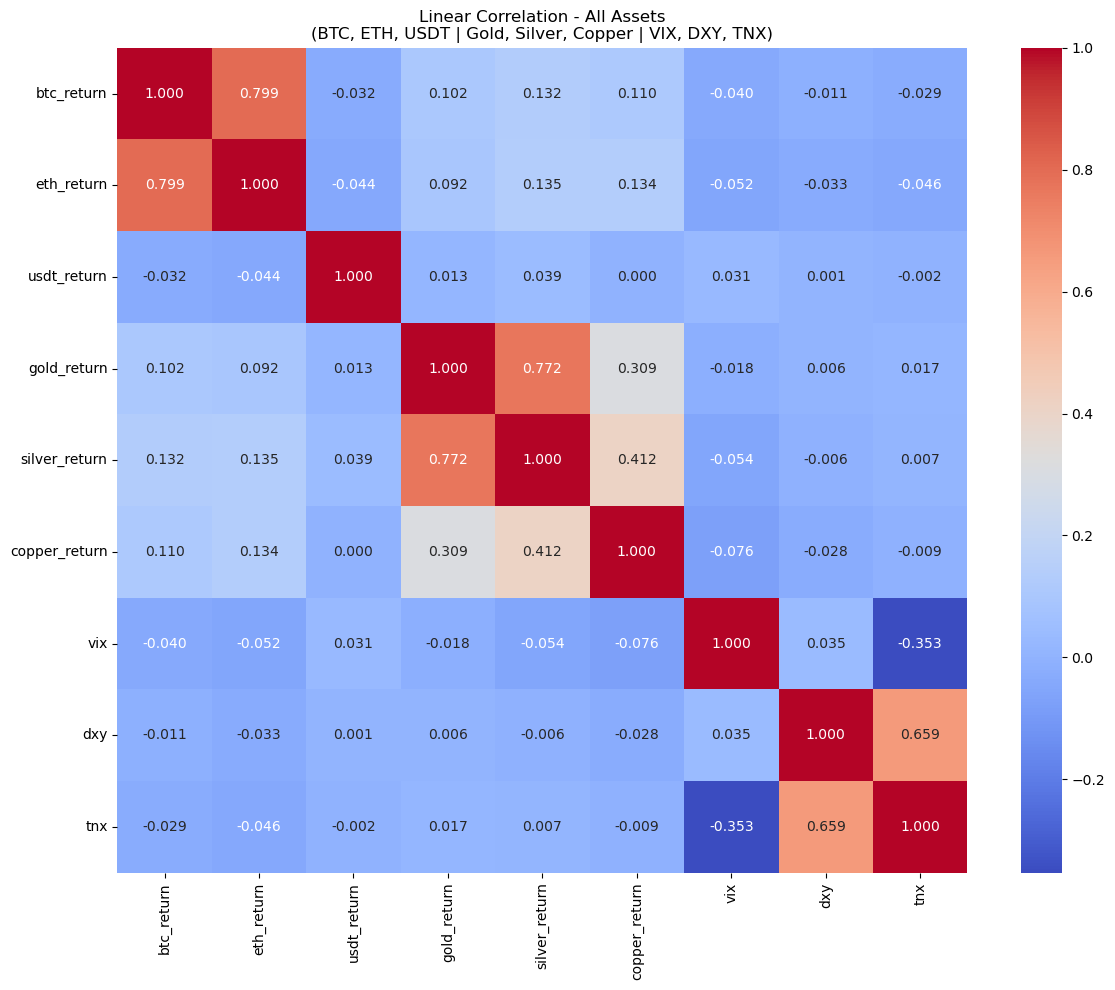

In [10]:
# Compute Pearson correlation matrix for asset returns and risk indicators
# Correlation measures linear dependence between variable pairs
# Values range from negative one to positive one
corr = df[['btc_return','eth_return','usdt_return','gold_return','silver_return','copper_return','vix','dxy','tnx']].corr()

# Visualize correlation matrix as annotated heatmap
# Color intensity indicates correlation strength and direction
# Annotations provide precise numerical values for interpretation
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("Linear Correlation - All Assets\n(BTC, ETH, USDT | Gold, Silver, Copper | VIX, DXY, TNX)")
plt.tight_layout()
plt.show()

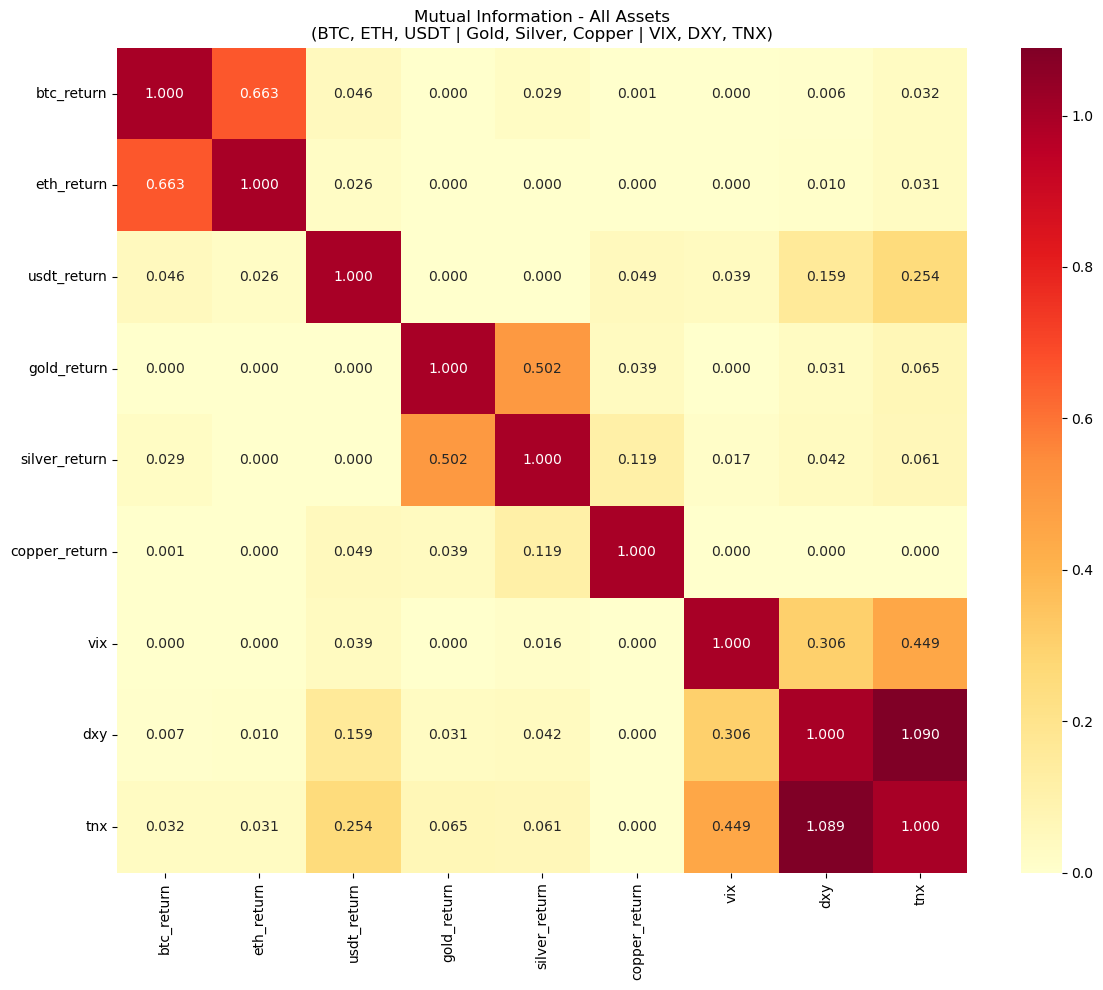

Mutual Information Matrix:
               btc_return  eth_return  usdt_return  gold_return  \
btc_return       1.000000    0.662694     0.046326     0.000000   
eth_return       0.662694    1.000000     0.025504     0.000000   
usdt_return      0.046326    0.025504     1.000000     0.000000   
gold_return      0.000000    0.000000     0.000000     1.000000   
silver_return    0.029216    0.000000     0.000000     0.501934   
copper_return    0.001049    0.000000     0.048552     0.038803   
vix              0.000000    0.000000     0.038686     0.000000   
dxy              0.006598    0.010469     0.158907     0.031035   
tnx              0.031790    0.030981     0.254333     0.064715   

               silver_return  copper_return       vix       dxy       tnx  
btc_return          0.029216       0.001127  0.000000  0.006292  0.031841  
eth_return          0.000000       0.000000  0.000000  0.010432  0.031125  
usdt_return         0.000000       0.048745  0.039288  0.159079  0.253924 

In [11]:
# Define columns for mutual information analysis
# Mutual information captures both linear and non linear dependencies
# Provides complementary insights to Pearson correlation
return_cols = ['btc_return','eth_return','usdt_return','gold_return','silver_return','copper_return','vix','dxy','tnx']

# Define function to compute pairwise mutual information matrix
# Uses sklearn mutual_info_regression for non parametric estimation
# Higher values indicate stronger statistical dependence
def compute_mi_matrix(df, columns):
    n = len(columns)
    mi_matrix = np.zeros((n, n))
    for i, col1 in enumerate(columns):
        for j, col2 in enumerate(columns):
            if i == j:
                mi_matrix[i, j] = 1.0
            else:
                X = df[[col1]].values
                y = df[col2].values
                mi = mutual_info_regression(X, y, random_state=42)[0]
                mi_matrix[i, j] = mi
    return pd.DataFrame(mi_matrix, index=columns, columns=columns)

# Compute mutual information matrix and visualize as heatmap
# Yellow to red color gradient indicates increasing dependence strength
mi_matrix = compute_mi_matrix(df, return_cols)

plt.figure(figsize=(12, 10))
sns.heatmap(mi_matrix, annot=True, cmap='YlOrRd', fmt='.3f')
plt.title("Mutual Information - All Assets\n(BTC, ETH, USDT | Gold, Silver, Copper | VIX, DXY, TNX)")
plt.tight_layout()
plt.show()

# Print numerical mutual information values for detailed analysis
print("Mutual Information Matrix:")
print(mi_matrix)

In [12]:
# Segment dataset into high risk and low risk periods based on VIX threshold
# VIX above 30 indicates elevated market fear and uncertainty
# VIX at or below 30 represents normal market conditions
risk_df = df[df['vix'] > 30]

# Analyze asset performance during high volatility periods
# Negative returns during risk periods suggest flight to quality behavior
print("=== Risk Period (VIX > 30) ===")
print("BTC mean return:", risk_df['btc_return'].mean())
print("ETH mean return:", risk_df['eth_return'].mean())
print("Gold mean return:", risk_df['gold_return'].mean())
print("Silver mean return:", risk_df['silver_return'].mean())
print("Copper mean return:", risk_df['copper_return'].mean())

# Define low risk period subset for comparative analysis
safe_df = df[df['vix'] <= 30]

# Analyze asset performance during normal market conditions
# Positive returns indicate favorable risk taking environment
print("\n=== Safe Period (VIX <= 30) ===")
print("BTC mean return:", safe_df['btc_return'].mean())
print("ETH mean return:", safe_df['eth_return'].mean())
print("Gold mean return:", safe_df['gold_return'].mean())
print("Silver mean return:", safe_df['silver_return'].mean())
print("Copper mean return:", safe_df['copper_return'].mean())

=== Risk Period (VIX > 30) ===
BTC mean return: -0.004409483681634618
ETH mean return: -0.009274712348553996
Gold mean return: 0.0013345645817406404
Silver mean return: 0.00011832657901951336
Copper mean return: -0.0020580297684280636

=== Safe Period (VIX <= 30) ===
BTC mean return: 0.0020286854365728396
ETH mean return: 0.002792658958722941
Gold mean return: 0.0006019977724124517
Silver mean return: 0.0010132274966619232
Copper mean return: 0.0005797401091816341


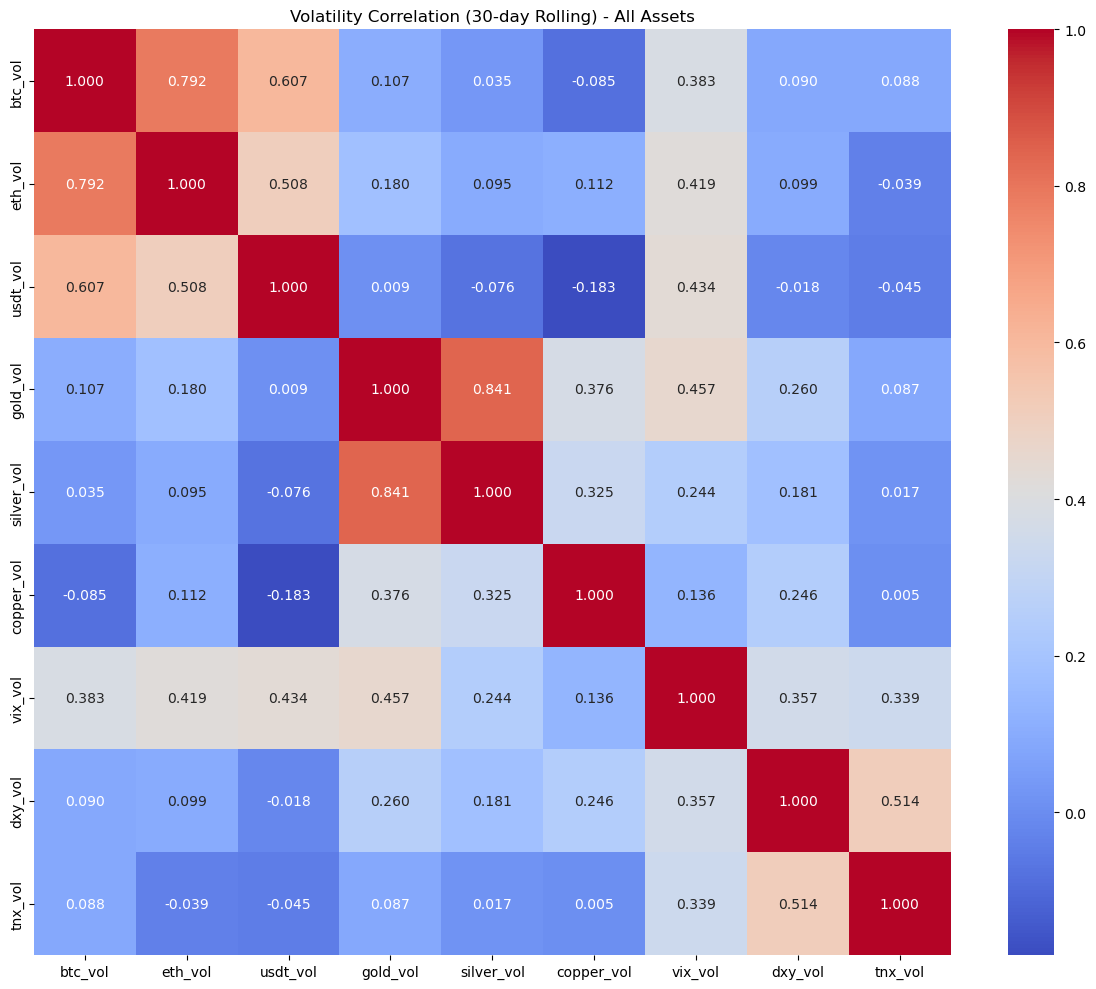

In [13]:
# Define volatility columns for correlation analysis
# Examines co movement in asset volatility rather than returns
# Volatility correlation reveals common risk factor exposure
vol_cols = ['btc_vol','eth_vol','usdt_vol','gold_vol','silver_vol','copper_vol','vix_vol','dxy_vol','tnx_vol']
corr_vol = df[vol_cols].corr()

# Visualize volatility correlation structure across all assets
# High volatility correlation suggests shared risk factors
# Low correlation indicates diversification benefits
plt.figure(figsize=(12, 10))
sns.heatmap(corr_vol, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("Volatility Correlation (30-day Rolling) - All Assets")
plt.tight_layout()
plt.show()

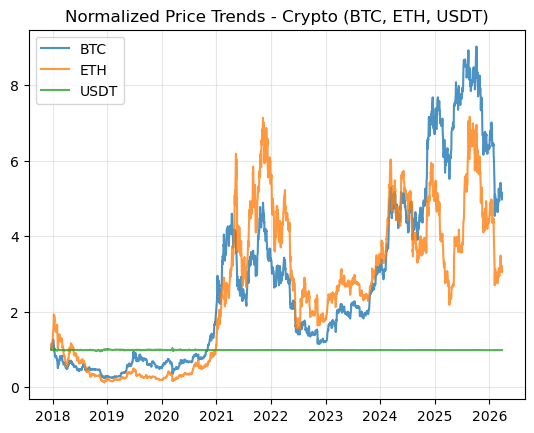

In [14]:
# Create multi panel visualization of normalized price trends
# Normalization to base period enables cross asset comparison
# First panel displays cryptocurrency price evolution
# plt.figure(figsize=(14, 10))

# plt.subplot(3, 1, 1)
# Normalize prices to first observation for relative performance comparison
norm_btc = df['btc_close'] / df['btc_close'].iloc[0]
norm_eth = df['eth_close'] / df['eth_close'].iloc[0]
norm_usdt = df['usdt_close'] / df['usdt_close'].iloc[0]

plt.plot(df.index, norm_btc, label='BTC', alpha=0.8)
plt.plot(df.index, norm_eth, label='ETH', alpha=0.8)
plt.plot(df.index, norm_usdt, label='USDT', alpha=0.8)
plt.title('Normalized Price Trends - Crypto (BTC, ETH, USDT)')
plt.legend()
plt.grid(True, alpha=0.3)

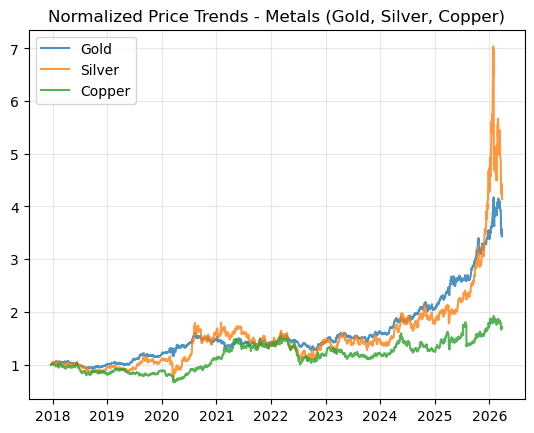

In [15]:
# Second panel displays precious and industrial metals price evolution
# plt.subplot(3, 1, 2)
norm_gold = df['gold_close'] / df['gold_close'].iloc[0]
norm_silver = df['silver_close'] / df['silver_close'].iloc[0]
norm_copper = df['copper_close'] / df['copper_close'].iloc[0]

plt.plot(df.index, norm_gold, label='Gold', alpha=0.8)
plt.plot(df.index, norm_silver, label='Silver', alpha=0.8)
plt.plot(df.index, norm_copper, label='Copper', alpha=0.8)
plt.title('Normalized Price Trends - Metals (Gold, Silver, Copper)')
plt.legend()
plt.grid(True, alpha=0.3)

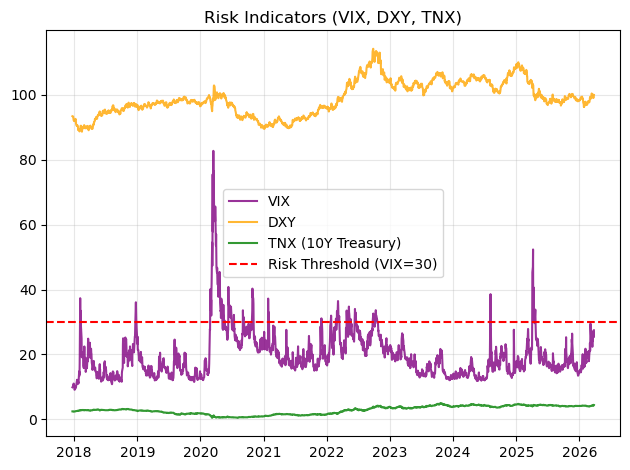

In [16]:
# Third panel displays risk indicators over time
# plt.subplot(3, 1, 3)
plt.plot(df.index, df['vix'], label='VIX', color='purple', alpha=0.8)
plt.plot(df.index, df['dxy'], label='DXY', color='orange', alpha=0.8)
plt.plot(df.index, df['tnx'], label='TNX (10Y Treasury)', color='green', alpha=0.8)
# Add horizontal line at VIX 30 to mark risk threshold
plt.axhline(y=30, color='red', linestyle='--', label='Risk Threshold (VIX=30)')
plt.title('Risk Indicators (VIX, DXY, TNX)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

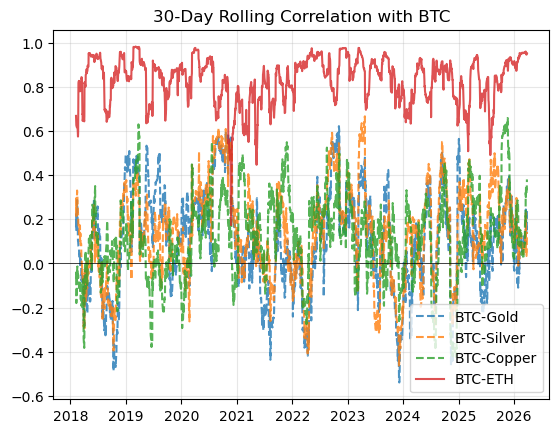

In [17]:
# Analyze time varying correlation between Bitcoin and other assets
# Rolling correlation captures dynamic relationship changes over time
# 30 day window balances responsiveness with stability
# plt.figure(figsize=(14, 12))

# plt.subplot(2, 1, 1)
# Compute rolling correlations between BTC and metal assets
rolling_corr_gold = df['btc_return'].rolling(30).corr(df['gold_return'])
rolling_corr_silver = df['btc_return'].rolling(30).corr(df['silver_return'])
rolling_corr_copper = df['btc_return'].rolling(30).corr(df['copper_return'])
rolling_corr_eth = df['btc_return'].rolling(30).corr(df['eth_return'])

# Plot rolling correlations to visualize relationship dynamics
plt.plot(df.index, rolling_corr_gold, label='BTC-Gold', linestyle='--', alpha=0.8)
plt.plot(df.index, rolling_corr_silver, label='BTC-Silver', linestyle='--', alpha=0.8)
plt.plot(df.index, rolling_corr_copper, label='BTC-Copper', linestyle='--', alpha=0.8)
plt.plot(df.index, rolling_corr_eth, label='BTC-ETH', alpha=0.8)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.title('30-Day Rolling Correlation with BTC')
plt.legend()
plt.grid(True, alpha=0.3)

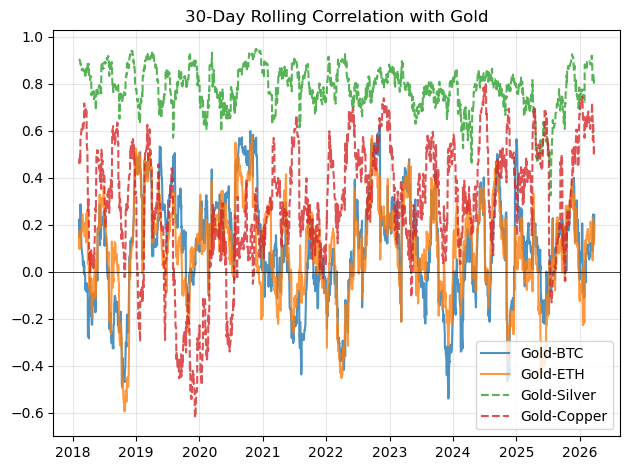

In [18]:
# Second subplot examines correlation with risk indicators
# plt.subplot(2, 1, 2)
gold_corr_btc = df['gold_return'].rolling(30).corr(df['btc_return'])
gold_corr_eth = df['gold_return'].rolling(30).corr(df['eth_return'])
gold_corr_silver = df['gold_return'].rolling(30).corr(df['silver_return'])
gold_corr_copper = df['gold_return'].rolling(30).corr(df['copper_return'])

plt.plot(df.index, gold_corr_btc, label='Gold-BTC', alpha=0.8)
plt.plot(df.index, gold_corr_eth, label='Gold-ETH', alpha=0.8)
plt.plot(df.index, gold_corr_silver, label='Gold-Silver', linestyle='--', alpha=0.8)
plt.plot(df.index, gold_corr_copper, label='Gold-Copper', linestyle='--', alpha=0.8)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.title('30-Day Rolling Correlation with Gold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Part 4: Capital Asset Pricing Model Analysis

In [19]:
# Using Capital Asset Pricing Model analysis to estimate expected returns
# Analyze relationship between Treasury yields and asset performance
print("=== TNX (10-Year Treasury Yield) Analysis ===")
print(f"TNX mean: {df['tnx'].mean():.4f}")
print(f"TNX std: {df['tnx'].std():.4f}")

# Segment data by yield level to examine interest rate sensitivity
# High yield period defined as above 75th percentile
high_yield_df = df[df['tnx'] > df['tnx'].quantile(0.75)]
# Low yield period defined as below 25th percentile
low_yield_df = df[df['tnx'] <= df['tnx'].quantile(0.25)]

# Compare asset returns across different yield environments
print("\n=== High Yield Period (TNX > 75th percentile) ===")
print("BTC mean return:", high_yield_df['btc_return'].mean())
print("ETH mean return:", high_yield_df['eth_return'].mean())
print("Gold mean return:", high_yield_df['gold_return'].mean())

print("\n=== Low Yield Period (TNX <= 25th percentile) ===")
print("BTC mean return:", low_yield_df['btc_return'].mean())
print("ETH mean return:", low_yield_df['eth_return'].mean())
print("Gold mean return:", low_yield_df['gold_return'].mean())

=== TNX (10-Year Treasury Yield) Analysis ===
TNX mean: 2.8816
TNX std: 1.2599

=== High Yield Period (TNX > 75th percentile) ===
BTC mean return: 0.0013533939495433845
ETH mean return: 0.0005424276339590148
Gold mean return: 0.0013577483128250762

=== Low Yield Period (TNX <= 25th percentile) ===
BTC mean return: 0.004188219893631504
ETH mean return: 0.007612068174598115
Gold mean return: 0.00044450232127318107


In [20]:
# Mean Variance Portfolio Optimization using Markowitz framework
# Construct optimal portfolios balancing return and risk
print("=" * 70)
print("CAPM Asset Pricing Model - Portfolio Construction")
print("Based on Low Correlation between Metals and Crypto")
print("=" * 70)

# Derive risk free rate from observed Treasury yield
# Convert annual rate to daily for consistency with return calculations
rf_daily = float(df['tnx'].mean()) / 252
rf_annual = rf_daily * 252
print(f"\nRisk-free rate (daily): {rf_daily:.6f}%")
print(f"Risk-free rate (annual): {rf_annual:.4f}%")

# Prepare clean dataset for portfolio analysis
df_clean = df[['btc_return', 'eth_return', 'gold_return', 'silver_return', 'copper_return', 'vix', 'dxy', 'tnx']].dropna().copy()
print(f"\nData period: {df_clean.index[0].strftime('%Y-%m-%d')} to {df_clean.index[-1].strftime('%Y-%m-%d')}")
print(f"Number of observations: {len(df_clean)}")

# Import optimization and regression tools
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize

def capm_expected_return(beta, market_return_avg, rf):
    return rf + beta * (market_return_avg - rf)

# Define CAPM expected return calculation function
# Expected return equals risk free rate plus beta times market risk premium
def capm_regression(asset_vals, market_vals, rf):
    excess_asset = asset_vals - rf
    excess_market = market_vals - rf
    X = excess_market.reshape(-1, 1)
    model = LinearRegression().fit(X, excess_asset)
    return model

def portfolio_stats(weights, mean_returns, cov_matrix, rf):
    port_return = np.dot(weights, mean_returns)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (port_return - rf) / port_vol if port_vol > 1e-10 else 0
    return port_return, port_vol, sharpe

print("\n" + "=" * 70)


CAPM Asset Pricing Model - Portfolio Construction
Based on Low Correlation between Metals and Crypto

Risk-free rate (daily): 0.011435%
Risk-free rate (annual): 2.8816%

Data period: 2017-12-22 to 2026-03-26
Number of observations: 2073



In [21]:
# Using Monte Carlo simulation to visualize the efficient frontier
# Execute CAPM regression analysis for each portfolio asset
print("STEP 1: CAPM Regression Analysis")
print("=" * 70)

# Construct market proxy as equal weighted metal portfolio
# Metals provide traditional store of value comparison for crypto assets
market_return_daily = (df_clean['gold_return'] + df_clean['silver_return'] + df_clean['copper_return']).values / 3
market_return_avg = np.mean(market_return_daily)
print(f"\nMetal Market (Gold+Silver+Copper) Average Return: {market_return_avg:.6f} (daily)")

# Define asset universe for CAPM analysis
assets_config = [
    ('BTC', 'btc_return'),
    ('ETH', 'eth_return'),
    ('Gold', 'gold_return'),
    ('Silver', 'silver_return'),
    ('Copper', 'copper_return')
]

# Execute CAPM regression for each asset
capm_results = {}
for asset_name, col in assets_config:
    asset_vals = df_clean[col].values.astype(float)
    model = capm_regression(asset_vals, market_return_daily, rf_daily)
    beta = model.coef_[0]
    alpha = model.intercept_
    expected_ret = capm_expected_return(beta, market_return_avg, rf_daily)
    capm_results[asset_name] = {
        'alpha': alpha,
        'beta': beta,
        'expected_return': expected_ret
    }
    print(f"\n{asset_name}:")
    print(f"  Alpha (excess return): {alpha:.6f}")
    print(f"  Beta (market sensitivity): {beta:.4f}")
    print(f"  CAPM Expected Return: {expected_ret:.6f} ({expected_ret*100:.4f}% daily)")

print("\n" + "=" * 70)


STEP 1: CAPM Regression Analysis

Metal Market (Gold+Silver+Copper) Average Return: 0.000663 (daily)

BTC:
  Alpha (excess return): -0.005209
  Beta (market sensitivity): 0.4335
  CAPM Expected Return: 0.006766 (0.6766% daily)

ETH:
  Alpha (excess return): -0.003003
  Beta (market sensitivity): 0.6057
  CAPM Expected Return: 0.004911 (0.4911% daily)

Gold:
  Alpha (excess return): -0.003817
  Beta (market sensitivity): 0.6464
  CAPM Expected Return: 0.004472 (0.4472% daily)

Silver:
  Alpha (excess return): 0.005911
  Beta (market sensitivity): 1.5224
  CAPM Expected Return: -0.004964 (-0.4964% daily)

Copper:
  Alpha (excess return): -0.002095
  Beta (market sensitivity): 0.8313
  CAPM Expected Return: 0.002481 (0.2481% daily)



In [22]:
# Print final portfolio allocation summary
# Execute mean variance optimization for portfolio construction
print("STEP 2: Portfolio Optimization")
print("=" * 70)

# Prepare return data matrix for optimization
returns_cols = ['btc_return', 'eth_return', 'gold_return', 'silver_return', 'copper_return']
asset_names = ['BTC', 'ETH', 'Gold', 'Silver', 'Copper']
returns_data = df_clean[returns_cols].values

# Compute covariance matrix for risk estimation
cov_matrix = np.cov(returns_data.T)
# Compute mean returns for expected return estimation
mean_returns = np.mean(returns_data, axis=0)

# Initialize optimization with equal weight starting point
n_assets = len(returns_cols)
initial_weights = np.array([1.0 / n_assets] * n_assets)

# Define constraints for long only portfolio with full investment
bounds = tuple((0, 1) for _ in range(n_assets))
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

# Minimize portfolio volatility subject to constraints
# Objective function extracts volatility from portfolio_stats output
# SLSQP method handles both bounds and equality constraints
result_min_vol = minimize(
    lambda w: portfolio_stats(w, mean_returns, cov_matrix, rf_daily)[1],
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-12}
)

# Extract optimal weights from optimization result
min_vol_weights = result_min_vol.x
min_vol_return, min_vol_vol, min_vol_sharpe = portfolio_stats(min_vol_weights, mean_returns, cov_matrix, rf_daily)

# Maximize Sharpe ratio by minimizing negative Sharpe ratio
# Negative sign converts maximization to minimization problem
result_max_sharpe = minimize(
    lambda w: -portfolio_stats(w, mean_returns, cov_matrix, rf_daily)[2],
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-12}
)

# Extract optimal weights for maximum Sharpe ratio portfolio
max_sharpe_weights = result_max_sharpe.x
max_sharpe_return, max_sharpe_vol, max_sharpe_sharpe = portfolio_stats(max_sharpe_weights, mean_returns, cov_matrix, rf_daily)

# Display minimum volatility portfolio allocation
print("\n>>> MINIMUM VOLATILITY PORTFOLIO <<<")
print("-" * 60)
print(f"{'Asset':<12} {'Weight':>10} {'CAPM Expected Ret':>20}")
print("-" * 60)
for i, name in enumerate(asset_names):
    w = min_vol_weights[i]
    exp_ret = capm_results[name]['expected_return']
    print(f"{name:<12} {w*100:>9.2f}% {exp_ret*100:>19.4f}%")
print("-" * 60)
print(f"{'TOTAL':<12} {np.sum(min_vol_weights)*100:>9.2f}%")
print(f"\n{'Metric':<25} {'Value':>15}")
print("-" * 45)
print(f"{'Daily Return':<25} {min_vol_return:.6f}")
print(f"{'Annual Return':<25} {min_vol_return*252:.4f} ({min_vol_return*252*100:.2f}%)")
print(f"{'Daily Volatility':<25} {min_vol_vol:.6f}")
print(f"{'Annual Volatility':<25} {min_vol_vol*np.sqrt(252):.4f} ({min_vol_vol*np.sqrt(252)*100:.2f}%)")
print(f"{'Sharpe Ratio':<25} {min_vol_sharpe:.4f}")

# Display maximum Sharpe ratio portfolio allocation
print("\n>>> MAXIMUM SHARPE RATIO PORTFOLIO <<<")
print("-" * 60)
print(f"{'Asset':<12} {'Weight':>10} {'CAPM Expected Ret':>20}")
print("-" * 60)
for i, name in enumerate(asset_names):
    w = max_sharpe_weights[i]
    exp_ret = capm_results[name]['expected_return']
    print(f"{name:<12} {w*100:>9.2f}% {exp_ret*100:>19.4f}%")
print("-" * 60)
print(f"{'TOTAL':<12} {np.sum(max_sharpe_weights)*100:>9.2f}%")
print(f"\n{'Metric':<25} {'Value':>15}")
print("-" * 45)
print(f"{'Daily Return':<25} {max_sharpe_return:.6f}")
print(f"{'Annual Return':<25} {max_sharpe_return*252:.4f} ({max_sharpe_return*252*100:.2f}%)")
print(f"{'Daily Volatility':<25} {max_sharpe_vol:.6f}")
print(f"{'Annual Volatility':<25} {max_sharpe_vol*np.sqrt(252):.4f} ({max_sharpe_vol*np.sqrt(252)*100:.2f}%)")
print(f"{'Sharpe Ratio':<25} {max_sharpe_sharpe:.4f}")

print("\n" + "=" * 70)

STEP 2: Portfolio Optimization

>>> MINIMUM VOLATILITY PORTFOLIO <<<
------------------------------------------------------------
Asset            Weight    CAPM Expected Ret
------------------------------------------------------------
BTC               2.96%              0.6766%
ETH               0.00%              0.4911%
Gold             74.45%              0.4472%
Silver            0.00%             -0.4964%
Copper           22.59%              0.2481%
------------------------------------------------------------
TOTAL           100.00%

Metric                              Value
---------------------------------------------
Daily Return              0.000622
Annual Return             0.1566 (15.66%)
Daily Volatility          0.009943
Annual Volatility         0.1578 (15.78%)
Sharpe Ratio              -1.0875

>>> MAXIMUM SHARPE RATIO PORTFOLIO <<<
------------------------------------------------------------
Asset            Weight    CAPM Expected Ret
-------------------------------

STEP 3: Efficient Frontier Visualization


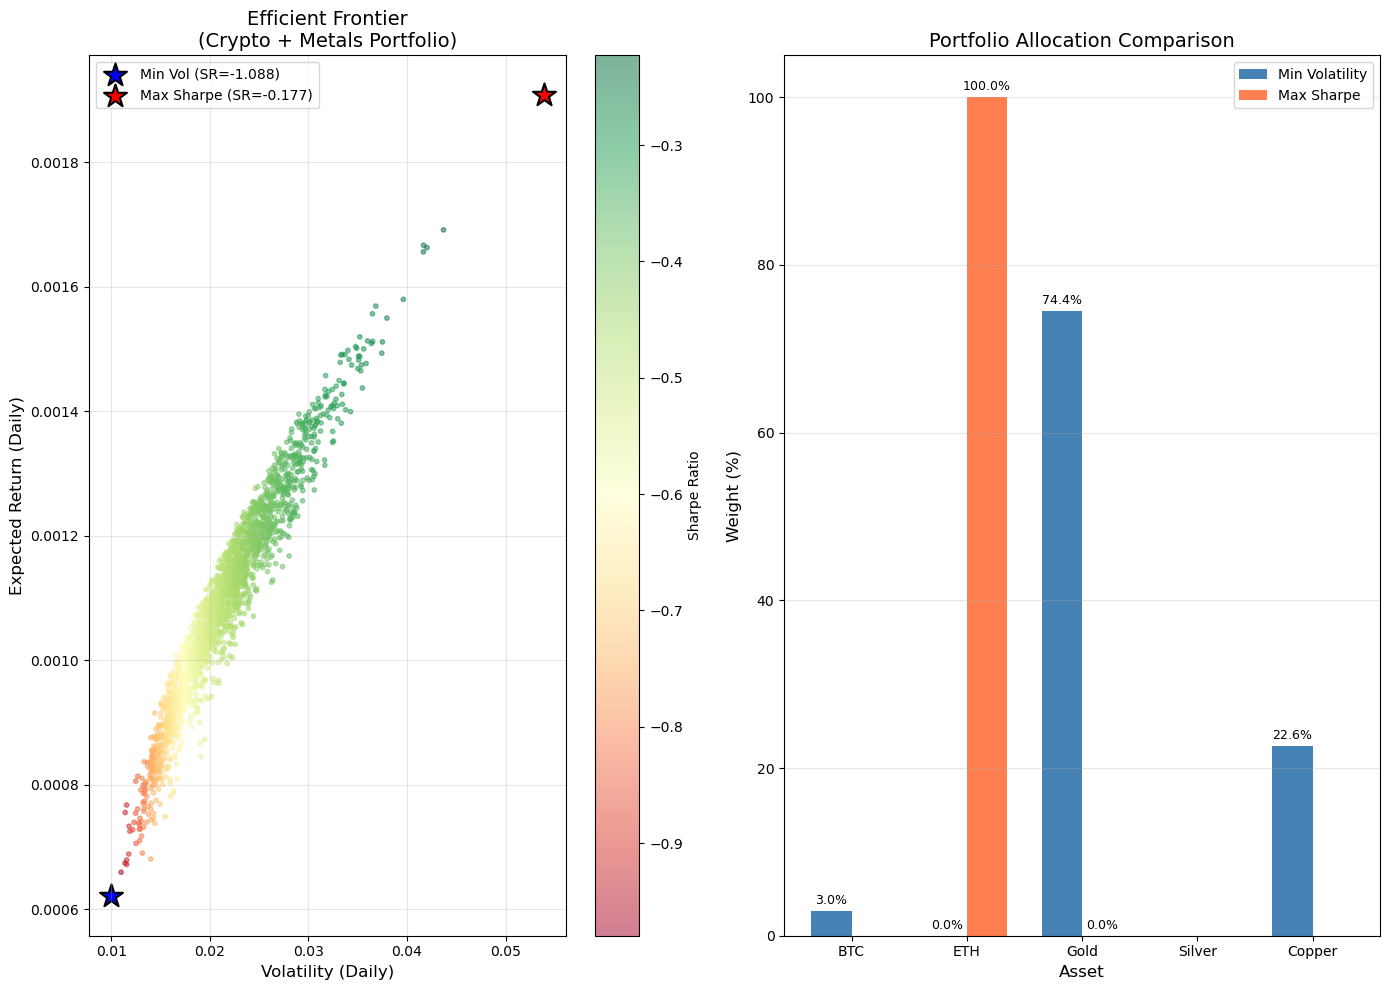


SUMMARY

Metric                          Min Volatility           Max Sharpe
----------------------------------------------------------------------
Annual Return                           15.66%               48.08%
Annual Volatility                       15.78%               85.56%
Sharpe Ratio                           -1.0875              -0.1768
----------------------------------------------------------------------
BTC Weight                               2.96%                0.00%
ETH Weight                               0.00%              100.00%
Gold Weight                             74.45%                0.00%
Silver Weight                            0.00%                0.00%
Copper Weight                           22.59%                0.00%



In [23]:
# Visualize efficient frontier through Monte Carlo simulation
print("STEP 3: Efficient Frontier Visualization")
print("=" * 70)

np.random.seed(42)
monte_carlo_results = []
# Generate 2000 random portfolios to map the feasible investment region
for _ in range(2000):
    weights = np.random.random(n_assets)
    weights /= np.sum(weights)
    ret, vol, sharpe = portfolio_stats(weights, mean_returns, cov_matrix, rf_daily)
    monte_carlo_results.append([ret, vol, sharpe])
# Convert results to numpy array for efficient array operations
monte_carlo_results = np.array(monte_carlo_results)

plt.figure(figsize=(14, 10))
# First subplot displays efficient frontier scatter plot
plt.subplot(1, 2, 1)
# Create scatter plot with volatility on x axis and return on y axis
# Color represents Sharpe ratio with red for low and green for high
scatter = plt.scatter(monte_carlo_results[:, 1], monte_carlo_results[:, 0], 
                     c=monte_carlo_results[:, 2], cmap='RdYlGn', alpha=0.5, s=10)
plt.colorbar(scatter, label='Sharpe Ratio')
plt.scatter(min_vol_vol, min_vol_return, marker='*', color='blue', s=300, 
            edgecolors='black', linewidths=1.5, label=f'Min Vol (SR={min_vol_sharpe:.3f})')
plt.scatter(max_sharpe_vol, max_sharpe_return, marker='*', color='red', s=300,
            edgecolors='black', linewidths=1.5, label=f'Max Sharpe (SR={max_sharpe_sharpe:.3f})')
plt.xlabel('Volatility (Daily)', fontsize=12)
plt.ylabel('Expected Return (Daily)', fontsize=12)
plt.title('Efficient Frontier\n(Crypto + Metals Portfolio)', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Second subplot compares portfolio allocations between strategies
plt.subplot(1, 2, 2)
x = np.arange(len(asset_names))
width = 0.35
bars1 = plt.bar(x - width/2, min_vol_weights * 100, width, label='Min Volatility', color='steelblue')
bars2 = plt.bar(x + width/2, max_sharpe_weights * 100, width, label='Max Sharpe', color='coral')
plt.xlabel('Asset', fontsize=12)
plt.ylabel('Weight (%)', fontsize=12)
plt.title('Portfolio Allocation Comparison', fontsize=14)
plt.xticks(x, asset_names)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Add weight percentage labels above each bar for minimum volatility portfolio
for bar in bars1:
    if bar.get_height() > 0:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
# Add weight percentage labels above each bar for maximum Sharpe ratio portfolio
for bar in bars2:
    if bar.get_height() > 0:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print comprehensive summary comparing both optimization strategies
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"\n{'Metric':<25} {'Min Volatility':>20} {'Max Sharpe':>20}")
print("-" * 70)
print(f"{'Annual Return':<25} {min_vol_return*252*100:>19.2f}% {max_sharpe_return*252*100:>19.2f}%")
print(f"{'Annual Volatility':<25} {min_vol_vol*np.sqrt(252)*100:>19.2f}% {max_sharpe_vol*np.sqrt(252)*100:>19.2f}%")
print(f"{'Sharpe Ratio':<25} {min_vol_sharpe:>20.4f} {max_sharpe_sharpe:>20.4f}")
print("-" * 70)
for i, name in enumerate(asset_names):
    print(f"{name + ' Weight':<25} {min_vol_weights[i]*100:>19.2f}% {max_sharpe_weights[i]*100:>19.2f}%")
print("=" * 70)

print("\n" + "=" * 70)

In [24]:
# Additional portfolio allocation summary with clean formatting
# Display final optimization results for both strategies
print("STEP 4: Final Asset Allocation Summary")
print("=" * 70)

# Present minimum volatility portfolio allocation
print("\n>>> MINIMUM VOLATILITY PORTFOLIO <<<")
print(f"  BTC:     {min_vol_weights[0]*100:6.2f}%")
print(f"  ETH:     {min_vol_weights[1]*100:6.2f}%")
print(f"  Gold:    {min_vol_weights[2]*100:6.2f}%")
print(f"  Silver:  {min_vol_weights[3]*100:6.2f}%")
print(f"  Copper:  {min_vol_weights[4]*100:6.2f}%")
print(f"  -----------------")
print(f"  Annual Return:    {min_vol_return*252*100:6.2f}%")
print(f"  Annual Volatility:{min_vol_vol*np.sqrt(252)*100:6.2f}%")
print(f"  Sharpe Ratio:     {min_vol_sharpe:6.4f}")

# Present maximum Sharpe ratio portfolio allocation
print("\n>>> MAXIMUM SHARPE RATIO PORTFOLIO <<<")
print(f"  BTC:     {max_sharpe_weights[0]*100:6.2f}%")
print(f"  ETH:     {max_sharpe_weights[1]*100:6.2f}%")
print(f"  Gold:    {max_sharpe_weights[2]*100:6.2f}%")
print(f"  Silver:  {max_sharpe_weights[3]*100:6.2f}%")
print(f"  Copper:  {max_sharpe_weights[4]*100:6.2f}%")
print(f"  -----------------")
print(f"  Annual Return:    {max_sharpe_return*252*100:6.2f}%")
print(f"  Annual Volatility:{max_sharpe_vol*np.sqrt(252)*100:6.2f}%")
print(f"  Sharpe Ratio:     {max_sharpe_sharpe:6.4f}")
print("=" * 70)

STEP 4: Final Asset Allocation Summary

>>> MINIMUM VOLATILITY PORTFOLIO <<<
  BTC:       2.96%
  ETH:       0.00%
  Gold:     74.45%
  Silver:    0.00%
  Copper:   22.59%
  -----------------
  Annual Return:     15.66%
  Annual Volatility: 15.78%
  Sharpe Ratio:     -1.0875

>>> MAXIMUM SHARPE RATIO PORTFOLIO <<<
  BTC:       0.00%
  ETH:     100.00%
  Gold:      0.00%
  Silver:    0.00%
  Copper:    0.00%
  -----------------
  Annual Return:     48.08%
  Annual Volatility: 85.56%
  Sharpe Ratio:     -0.1768
